## Modelo de Detecção de Textos Maliciosos com PLN e Aprendizado de Máquina | Benchmark BoW vs. TF-IDF
**Modelo de classificação binária de texto**



In [65]:
# Import das bibliotecas necessárias para os modelos.

import pandas as pd
import numpy as np


In [66]:
# Import do dataset "TExtPhish" - HuggingFace.

dataset = pd.read_csv("textphish_train.csv")

print (dataset)

           src                                            content      label
0       reddit  There's also a written version I recently got ...  blackmail
1       reddit  Subject: Your personal life is about to get sh...  blackmail
2       reddit  Well i'm going to ensure it is as fast and sho...  blackmail
3       reddit   First Last As you have been abusing yourself ...  blackmail
4       reddit  If you dont send the money within 23 hours sin...  blackmail
...        ...                                                ...        ...
123433   Enron  The State Restructuring Service includes o New...     benign
123434   Enron  Then in the next paragraph we say again: sold ...     benign
123435   Enron  Susan Leblanc has spoken preliminarily with th...     benign
123436   Enron            Hopefully you will be able to retrieve.     benign
123437   Enron  Attached is a form of Master Energy Purchase a...     benign

[123438 rows x 3 columns]


In [67]:
# 1. Carregamento dos dados

X = dataset["content"]   # X (textos)
y = dataset["label"]     # y (rótulos)

In [68]:
dataset["label"].unique()    # Verificação dos valores de saída

array(['blackmail', 'sextortion', 'ransomware', 'benign'], dtype=object)

In [69]:
# Utilização do LabelEncoder para converter o y categórico em texto ("blackmail", "sextortion", "ransomware", "benign") em rótulos numéricos.

import sklearn as skl
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# OBS: A conversão ocorre em ordem lexicográfica ("[0] = benign", "[1] = blackmail", "[2] = ransomware", "[3] = sextortion")

rotulos = pd.Series(y_encoded)
print(rotulos.unique())          # valores únicos (ordem de aparição)
print(rotulos.value_counts())    # contagem por valor



[1 3 2 0]
0    83106
3    24724
1     8880
2     6728
Name: count, dtype: int64


In [70]:
# 2. Pré-processamento

# A. Normalização de case
dataset["content"] = dataset["content"].str.strip().str.lower()

# Verificando o resultado
print(dataset.head())

      src                                            content      label
0  reddit  there's also a written version i recently got ...  blackmail
1  reddit  subject: your personal life is about to get sh...  blackmail
2  reddit  well i'm going to ensure it is as fast and sho...  blackmail
3  reddit  first last as you have been abusing yourself i...  blackmail
4  reddit  if you dont send the money within 23 hours sin...  blackmail


In [71]:
# B. Tokenização 
import nltk
from nltk import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

def tokenizacao(texto):
    
    if not isinstance(texto, str): # Verifica se é string para evitar erros com valores nulos
        return ""
    
    tokens = word_tokenize(texto) # Tokeniza
    tokens_clean = [t for t in tokens if t.isalnum()] # remoção de pontuação como . , ! ?)

    return " ".join(tokens_clean)

dataset["content"] = dataset["content"].apply(tokenizacao)

print(dataset["content"].head())


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\David\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\David\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


0    there also a written version i recently got th...
1    subject your personal life is about to get sha...
2    well i going to ensure it is as fast and short...
3    first last as you have been abusing yourself i...
4    if you dont send the money within 23 hours sin...
Name: content, dtype: object


In [72]:
# C. Remoção de stopwords
from nltk.corpus import stopwords
nltk.download("stopwords", quiet=True)

stop_en = set(stopwords.words("english"))

def remove_stopwords(texto):
    if not isinstance(texto, str):
        return ""
    
    palavras = texto.split()
    filtradas = [w for w in palavras if w.lower() not in stop_en] # Divide a string em palavras, filtra as stopwords e junta novamente

    return " ".join(filtradas)

dataset["content"] = dataset["content"].apply(remove_stopwords) # Aplicação direta na coluna do DataFrame

print(dataset["content"].head()) # Verificação

0    also written version recently got regular mail...
1    subject personal life get shattered okay going...
2    well going ensure fast short month two back vi...
3    first last abusing front ofyour device screen ...
4    dont send money within 23 hours since moment r...
Name: content, dtype: object


In [73]:
# D. Lematização
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag

# Downloads necessários
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

lemmatizer = WordNetLemmatizer()
    
# Função auxiliar para converter tags do POS_TAG para o formato do WordNet    
def get_wordnet_pos(tag):
    if tag.startswith("J"): return wordnet.ADJ
    elif tag.startswith("V"): return wordnet.VERB
    elif tag.startswith("N"): return wordnet.NOUN
    elif tag.startswith("R"): return wordnet.ADV
    else: return wordnet.NOUN

# Função de processamento por linha (string única)
def lemmatize_text(texto):
    if not texto or not isinstance(texto, str):
        return ""
            
    # O texto já está tokenizado pelos passos anteriores
    tokens = texto.split()
        
    # Identifica as classes gramaticais
    pos_tags = pos_tag(tokens)
        
    # Lematiza usando a lógica interna
    lemmas = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]
    
    return " ".join(lemmas)
        
dataset["content"] = dataset["content"].apply(lemmatize_text) # Aplicação no DataFrame

print(dataset["content"].head()) # Verificação final

0    also write version recently get regular mail a...
1    subject personal life get shatter okay go make...
2    well go ensure fast short month two back visit...
3    first last abuse front ofyour device screen pa...
4    dont send money within 23 hour since moment re...
Name: content, dtype: object


In [74]:
# Separação do conjunto de treino e teste (80%/20%).
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(dataset["content"], y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [75]:
# A. Criação da representação vetorial a partir dos textos préprocessados com BAG OF WORDS

from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer()

# Aprende o vocabulário e transforma o treino em frequências absolutas
X_treino_bow = bow_vectorizer.fit_transform(X_treino)

# Transforma o teste com base no vocabulário do treino
X_teste_bow = bow_vectorizer.transform(X_teste)

print(f"Dimensões da matriz BoW: {X_treino_bow.shape}")

Dimensões da matriz BoW: (98750, 170079)


In [76]:
# A. Criação da representação vetorial a partir dos textos préprocessados com TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer
tf_idf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X_treino_tf_idf = tf_idf_vectorizer.fit_transform(X_treino)
X_teste_tf_idf  = tf_idf_vectorizer.transform(X_teste)

In [77]:
# B. Padronização de todas as colunas (StandardScaler)

from sklearn.preprocessing import StandardScaler

# 1. Inicializa o escalonador mantendo os zeros como zeros
scaler_bow = StandardScaler(with_mean=False)

# 2. Fit apenas no treino 
X_treino_bow_std = scaler_bow.fit_transform(X_treino_bow)
X_teste_bow_std  = scaler_bow.transform(X_teste_bow)

scaler_tfidf = StandardScaler(with_mean=False)

# Fit apenas no treino
X_treino_tfidf_std = scaler_tfidf.fit_transform(X_treino_tf_idf)
X_teste_tfidf_std  = scaler_tfidf.transform(X_teste_tf_idf)

In [78]:
# A. Execução do Principal Component Analysis sobre o conjunto de testes

# Opção por não fazer essa etapa, pois: 
# Ocorreu erro de memória onde tenter manter 5.000 componentes para quase 100.000 linhas exige aproximadamente 3.69 GB de RAM contínua, o que o sistema não conseguiu liberar.

# from sklearn.decomposition import TruncatedSVD

# 1. NÃO use .toarray(). Use a matriz original padronizada (X_treino_tfidf_std)

# 2. Inicialize o TruncatedSVD. 
# Como você queria 90% da variância, uma boa estimativa para texto 
# é testar entre 100 e 500 componentes. Vamos começar com 300.
# svd = TruncatedSVD(n_components=5000, random_state=42)

# 3. Fit apenas no treino e transform em ambos
# X_treino_pca = svd.fit_transform(X_treino_tfidf_std)
# X_teste_pca  = svd.transform(X_teste_tfidf_std)

# 4. Verificação da Variância Explicada Acumulada
# variancia_acumulada = svd.explained_variance_ratio_.sum()

# print(f"Número de componentes: {X_treino_pca.shape[1]}")
# print(f"Variância preservada com {svd.n_components} componentes: {variancia_acumulada:.2%}")

In [79]:
# Otimização de hiperparâmetros (Bag of Words)

# 1. Bag of Words + Regressão Logística

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score

parametros_grid_regressao_logistica_bow = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}

# Inicializando o modelo com penalidade L2
modelo_regressao_logistica_bow = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)

grid_regressao_logistica_bow = GridSearchCV(
    estimator=modelo_regressao_logistica_bow, 
    param_grid=parametros_grid_regressao_logistica_bow, 
    scoring='accuracy', 
    cv=3, 
    verbose=2,
    n_jobs=1  # 1 processo por vez para economizar RAM
)

# Executando o treino/otimização
print("Iniciando busca para Regressão Logística...")
grid_regressao_logistica_bow.fit(X_treino_bow_std, y_treino)

predicoes_regressao_logistica_bow = grid_regressao_logistica_bow.predict(X_teste_bow_std) 

acc_teste = accuracy_score(y_teste, predicoes_regressao_logistica_bow)
prec = precision_score(y_teste, predicoes_regressao_logistica_bow, average='weighted', zero_division=0)
rec = recall_score(y_teste, predicoes_regressao_logistica_bow, average='weighted', zero_division=0)

# Resultados
print("-" * 30)
print(f"Melhor valor de C: {grid_regressao_logistica_bow.best_params_['C']}")
print(f"Acurácia, Precision e Recall - Regressão Logística (BoW):")
print(f"Acurácia:  {acc_teste:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print("-" * 30)


Iniciando busca para Regressão Logística...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END ...........................................C=0.0001; total time=   5.0s
[CV] END ...........................................C=0.0001; total time=   4.6s
[CV] END ...........................................C=0.0001; total time=   4.7s
[CV] END ............................................C=0.001; total time=   3.6s
[CV] END ............................................C=0.001; total time=   3.7s
[CV] END ............................................C=0.001; total time=   4.1s
[CV] END .............................................C=0.01; total time=   3.3s
[CV] END .............................................C=0.01; total time=   4.0s
[CV] END .............................................C=0.01; total time=   3.5s
[CV] END ..............................................C=0.1; total time=   6.3s
[CV] END ..............................................C=0.1; total time=   7.5s
[CV] 

In [80]:
# 2. Bag of Words + Naïve Bayes

from sklearn.naive_bayes import GaussianNB

modelo_gnb_bow = GaussianNB()
modelo_gnb_bow.fit(X_treino_bow_std[:1000].toarray(), y_treino[:1000])

,priors,None
,var_smoothing,1e-09


In [81]:
# 3. Bag of Words + KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

parametros_grid_knn_bow = {'n_neighbors': [2, 4, 8, 12]}

modelo_knn_bow = KNeighborsClassifier()


grid_knn_bow = GridSearchCV(
    estimator=modelo_knn_bow, 
    param_grid=parametros_grid_knn_bow, 
    scoring='accuracy', 
    cv=3,       
    verbose=2,  
    n_jobs=1    # n_jobs=1 para não estourar a RAM
)

print("Iniciando busca para KNN...")
grid_knn_bow.fit(X_treino_bow_std, y_treino)

# Resultados
print("-" * 30)
print(f"Melhor valor de k: {grid_knn_bow.best_params_['n_neighbors']}")
print("-" * 30)

predicoes_knn_bow = grid_knn_bow.predict(X_teste_bow_std) 

acc = accuracy_score(y_teste, predicoes_knn_bow)
prec = precision_score(y_teste, predicoes_knn_bow, average='weighted', zero_division=0)
rec = recall_score(y_teste, predicoes_knn_bow, average='weighted', zero_division=0)

print(f"Acurácia, Precision e Recall - KNN (Bag of Words):")
print(f"Acurácia:  {acc_teste:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")


Iniciando busca para KNN...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ......................................n_neighbors=2; total time=  33.0s
[CV] END ......................................n_neighbors=2; total time=  32.1s
[CV] END ......................................n_neighbors=2; total time=  32.8s
[CV] END ......................................n_neighbors=4; total time=  31.5s
[CV] END ......................................n_neighbors=4; total time=  31.9s
[CV] END ......................................n_neighbors=4; total time=  34.2s
[CV] END ......................................n_neighbors=8; total time=  34.5s
[CV] END ......................................n_neighbors=8; total time=  34.1s
[CV] END ......................................n_neighbors=8; total time=  32.6s
[CV] END .....................................n_neighbors=12; total time=  31.8s
[CV] END .....................................n_neighbors=12; total time=  31.6s
[CV] END ............

In [82]:
# 4. Bag of Words + Rede Neural

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.utils import resample

# Reduzindo a carga: Amostra de 10% dos dados para a busca
X_amostra, y_amostra = resample(X_treino_bow_std, y_treino, n_samples=10000, random_state=42,  stratify=y_treino)

# Definindo as combinações de 3 camadas sugeridas
# A saida será: (2,2,2), (4,4,4), (8,8,8), (16,16,16) e (32,32,32)
neuronios = [2, 4, 8, 16, 32]
arquiteturas = [(n, n, n) for n in neuronios]

parametros_grid_mlp_bow = {'hidden_layer_sizes': arquiteturas, 'activation': ['relu'], 'solver': ['adam']}

# Inicializando o modelo
# max_iter=50 para convergência inicial
modelo_mlp_bow = MLPClassifier(max_iter=50, batch_size=512, early_stopping=True, random_state=42)

# Configurando o GridSearchCV
grid_mlp_bow = GridSearchCV(
    estimator=modelo_mlp_bow, 
    param_grid=parametros_grid_mlp_bow, 
    scoring='accuracy', 
    cv=3,       
    verbose=2, 
    n_jobs=1)

print("Iniciando busca para Rede Neural...")
grid_mlp_bow.fit(X_amostra, y_amostra)

predicoes_mlp_bow = grid_mlp_bow.predict(X_teste_bow_std) 

acc_teste = accuracy_score(y_teste, predicoes_mlp_bow)
prec = precision_score(y_teste, predicoes_mlp_bow, average='weighted', zero_division=0)
rec = recall_score(y_teste, predicoes_mlp_bow, average='weighted', zero_division=0)

# Resultados
print("-" * 30)
print(f"Melhor arquitetura: {grid_mlp_bow.best_params_['hidden_layer_sizes']}")
print(f"Acurácia, Precision e Recall - Rede Neural:")
print(f"Acurácia:  {acc_teste:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print("-" * 30)

Iniciando busca para Rede Neural...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END activation=relu, hidden_layer_sizes=(2, 2, 2), solver=adam; total time=   1.0s
[CV] END activation=relu, hidden_layer_sizes=(2, 2, 2), solver=adam; total time=   0.8s
[CV] END activation=relu, hidden_layer_sizes=(2, 2, 2), solver=adam; total time=   0.8s
[CV] END activation=relu, hidden_layer_sizes=(4, 4, 4), solver=adam; total time=   9.2s
[CV] END activation=relu, hidden_layer_sizes=(4, 4, 4), solver=adam; total time=   8.3s
[CV] END activation=relu, hidden_layer_sizes=(4, 4, 4), solver=adam; total time=   6.6s
[CV] END activation=relu, hidden_layer_sizes=(8, 8, 8), solver=adam; total time=  16.1s
[CV] END activation=relu, hidden_layer_sizes=(8, 8, 8), solver=adam; total time=  16.7s
[CV] END activation=relu, hidden_layer_sizes=(8, 8, 8), solver=adam; total time=  17.5s
[CV] END activation=relu, hidden_layer_sizes=(16, 16, 16), solver=adam; total time=  48.6s
[CV] END activation=r

In [83]:
# Otimização de hiperparâmetros (TF-IDF)

# 5. TF-IDF + Regressão Logística

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

parametros_grid_regressao_logistica_tfidf = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}

# Inicializando o modelo com penalidade L2
modelo_regressao_logistica_tfidf = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)

# Configurando o GridSearchCV
grid_regressao_logistica_tfidf = GridSearchCV(
    estimator=modelo_regressao_logistica_tfidf, 
    param_grid=parametros_grid_regressao_logistica_tfidf, 
    scoring='accuracy', 
    cv=3, 
    verbose=2,
    n_jobs=1  # 1 processo por vez para economizar RAM
)

# Executando o treino/otimização
print("Iniciando busca para Regressão Logística...")
grid_regressao_logistica_tfidf.fit(X_treino_tfidf_std, y_treino)

predicoes_regressao_logistica_tfidf = grid_regressao_logistica_tfidf.predict(X_teste_tfidf_std) 

acc_teste = accuracy_score(y_teste, predicoes_regressao_logistica_tfidf)
prec = precision_score(y_teste, predicoes_regressao_logistica_tfidf, average='weighted', zero_division=0)
rec = recall_score(y_teste, predicoes_regressao_logistica_tfidf, average='weighted', zero_division=0)

# Resultados
print("-" * 30)
print(f"Melhor valor de C: {grid_regressao_logistica_tfidf.best_params_['C']}")
print(f"Acurácia, Precision e Recall - Regressão Logística (TF-IDF):")
print(f"Acurácia:  {acc_teste:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print("-" * 30)


Iniciando busca para Regressão Logística...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END ...........................................C=0.0001; total time=   0.3s
[CV] END ...........................................C=0.0001; total time=   0.2s
[CV] END ...........................................C=0.0001; total time=   0.2s
[CV] END ............................................C=0.001; total time=   0.5s
[CV] END ............................................C=0.001; total time=   0.4s
[CV] END ............................................C=0.001; total time=   0.3s
[CV] END .............................................C=0.01; total time=   0.7s
[CV] END .............................................C=0.01; total time=   0.6s
[CV] END .............................................C=0.01; total time=   0.8s
[CV] END ..............................................C=0.1; total time=   1.2s
[CV] END ..............................................C=0.1; total time=   1.5s
[CV] 

In [84]:
# 6. TF-IDF + Naïve Bayes

from sklearn.naive_bayes import GaussianNB

modelo_gnb_tfidf = GaussianNB()
modelo_gnb_tfidf.fit(X_treino_tfidf_std[:1000].toarray(), y_treino[:1000])

,priors,None
,var_smoothing,1e-09


In [85]:
# 7. TF-IDF + KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

parametros_grid_knn_tfidf = {'n_neighbors': [2, 4, 8, 12]}

modelo_knn_tfidf = KNeighborsClassifier()


grid_knn_tfidf = GridSearchCV(
    estimator=modelo_knn_tfidf, 
    param_grid=parametros_grid_knn_tfidf, 
    scoring='accuracy', 
    cv=3,       
    verbose=2,  
    n_jobs=1    # n_jobs=1 para não estourar a RAM
)

print("Iniciando busca para KNN...")
grid_knn_tfidf.fit(X_treino_tfidf_std, y_treino)

# Resultados
print("-" * 30)
print(f"Melhor valor de k: {grid_knn_tfidf.best_params_['n_neighbors']}")
print("-" * 30)

predicoes_knn_tfidf = grid_knn_tfidf.predict(X_teste_tfidf_std) 

acc = accuracy_score(y_teste, predicoes_knn_tfidf)
prec = precision_score(y_teste, predicoes_knn_tfidf, average='weighted', zero_division=0)
rec = recall_score(y_teste, predicoes_knn_tfidf, average='weighted', zero_division=0)

print(f"Acurácia, Precision e Recall - KNN (TF-IDF):")
print(f"Acurácia:  {acc_teste:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")



Iniciando busca para KNN...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ......................................n_neighbors=2; total time=  37.7s
[CV] END ......................................n_neighbors=2; total time=  33.1s
[CV] END ......................................n_neighbors=2; total time=  31.1s
[CV] END ......................................n_neighbors=4; total time=  31.3s
[CV] END ......................................n_neighbors=4; total time=  32.4s
[CV] END ......................................n_neighbors=4; total time=  31.0s
[CV] END ......................................n_neighbors=8; total time=  32.3s
[CV] END ......................................n_neighbors=8; total time=  33.4s
[CV] END ......................................n_neighbors=8; total time=  31.2s
[CV] END .....................................n_neighbors=12; total time=  32.7s
[CV] END .....................................n_neighbors=12; total time=  32.4s
[CV] END ............

In [86]:
# 8. TF-IDF + Rede Neural

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

# Definindo as combinações de 3 camadas sugeridas
# A saida será: (2,2,2), (4,4,4), (8,8,8), (16,16,16) e (32,32,32)
neuronios = [2, 4, 8, 16, 32]
arquiteturas = [(n, n, n) for n in neuronios]

parametros_grid_mlp_tfidf = {'hidden_layer_sizes': arquiteturas, 'activation': ['relu'], 'solver': ['adam']}

# Inicializando o modelo
# max_iter=200 para convergência inicial
modelo_mlp_tfidf = MLPClassifier(max_iter=200, random_state=42)

# Configurando o GridSearchCV
grid_mlp_tfidf = GridSearchCV(
    estimator=modelo_mlp_tfidf, 
    param_grid=parametros_grid_mlp_tfidf, 
    scoring='accuracy', 
    cv=3,       
    verbose=2, 
    n_jobs=1)

print("Iniciando busca para Rede Neural...")
grid_mlp_tfidf.fit(X_treino_tfidf_std, y_treino)

predicoes_mlp_tfidf = grid_mlp_tfidf.predict(X_teste_tfidf_std) 

acc_teste = accuracy_score(y_teste, predicoes_mlp_tfidf)
prec = precision_score(y_teste, predicoes_mlp_tfidf, average='weighted', zero_division=0)
rec = recall_score(y_teste, predicoes_mlp_tfidf, average='weighted', zero_division=0)

# Resultados
print("-" * 30)
print(f"Melhor arquitetura: {grid_mlp_tfidf.best_params_['hidden_layer_sizes']}")
print(f"Acurácia, Precision e Recall - Rede Neural:")
print(f"Acurácia:  {acc_teste:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print("-" * 30)

Iniciando busca para Rede Neural...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END activation=relu, hidden_layer_sizes=(2, 2, 2), solver=adam; total time=  23.7s
[CV] END activation=relu, hidden_layer_sizes=(2, 2, 2), solver=adam; total time=  33.2s


C:\Users\David\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=relu, hidden_layer_sizes=(2, 2, 2), solver=adam; total time=  33.1s
[CV] END activation=relu, hidden_layer_sizes=(4, 4, 4), solver=adam; total time=  49.0s


C:\Users\David\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=relu, hidden_layer_sizes=(4, 4, 4), solver=adam; total time=  51.1s


C:\Users\David\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=relu, hidden_layer_sizes=(4, 4, 4), solver=adam; total time=  47.0s


C:\Users\David\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=relu, hidden_layer_sizes=(8, 8, 8), solver=adam; total time= 1.2min


C:\Users\David\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=relu, hidden_layer_sizes=(8, 8, 8), solver=adam; total time= 1.4min


C:\Users\David\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=relu, hidden_layer_sizes=(8, 8, 8), solver=adam; total time= 1.2min


C:\Users\David\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END activation=relu, hidden_layer_sizes=(16, 16, 16), solver=adam; total time= 3.1min
[CV] END activation=relu, hidden_layer_sizes=(16, 16, 16), solver=adam; total time= 2.7min
[CV] END activation=relu, hidden_layer_sizes=(16, 16, 16), solver=adam; total time= 3.0min
[CV] END activation=relu, hidden_layer_sizes=(32, 32, 32), solver=adam; total time= 3.5min
[CV] END activation=relu, hidden_layer_sizes=(32, 32, 32), solver=adam; total time= 3.3min
[CV] END activation=relu, hidden_layer_sizes=(32, 32, 32), solver=adam; total time= 3.2min
------------------------------
Melhor arquitetura: (32, 32, 32)
Acurácia, Precision e Recall - Rede Neural:
Acurácia:  0.7967
Precision: 0.7864
Recall:    0.7967
------------------------------


In [87]:
# Criação de uma lista contendo os resultados dos experimentos (Hiperparâmetros)
experimentos = [
    {'nome': 'Exp 1: BoW + Reg. Logística', 'objeto': grid_regressao_logistica_bow, 'dados_X': X_teste_bow_std},
    {'nome': 'Exp 3: BoW + KNN', 'objeto': grid_knn_bow, 'dados_X': X_teste_bow_std},
    {'nome': 'Exp 4: BoW + Rede Neural', 'objeto': grid_mlp_bow, 'dados_X': X_teste_bow_std},
    {'nome': 'Exp 5: TF-IDF + Reg. Logística', 'objeto': grid_regressao_logistica_tfidf, 'dados_X': X_teste_tfidf_std},
    {'nome': 'Exp 7: TF-IDF + KNN', 'objeto': grid_knn_tfidf, 'dados_X': X_teste_tfidf_std},
    {'nome': 'Exp 8: TF-IDF + Rede Neural', 'objeto': grid_mlp_tfidf, 'dados_X': X_teste_tfidf_std}
]

melhor_acuracia_teste = 0
vencedor = None

print("=== RANKING FINAL ===")

for exp in experimentos:
    preds = exp['objeto'].predict(exp['dados_X'])
    
    # 2. Calcula a acurácia de TESTE 
    acc_teste = accuracy_score(y_teste, preds)
    
    print(f"{exp['nome']}:")
    print(f"  > Acurácia de Teste: {acc_teste:.4f}")
    print(f"  > Melhores Parâmetros: {exp['objeto'].best_params_}")
    print("-" * 30)
    
    if acc_teste > melhor_acuracia_teste:
        melhor_acuracia_teste = acc_teste
        vencedor = exp

print("\n" + "*"*40)
print(f"MODELO VENCEDOR: {vencedor['nome']}")
print(f"Acurácia Final no Teste: {melhor_acuracia_teste:.4f}")
print(f"Melhores Hiperparâmetros: {vencedor['objeto'].best_params_}")
print("*"*40)

=== RANKING FINAL ===
Exp 1: BoW + Reg. Logística:
  > Acurácia de Teste: 0.8439
  > Melhores Parâmetros: {'C': 0.001}
------------------------------
Exp 3: BoW + KNN:
  > Acurácia de Teste: 0.7483
  > Melhores Parâmetros: {'n_neighbors': 4}
------------------------------
Exp 4: BoW + Rede Neural:
  > Acurácia de Teste: 0.7798
  > Melhores Parâmetros: {'activation': 'relu', 'hidden_layer_sizes': (32, 32, 32), 'solver': 'adam'}
------------------------------
Exp 5: TF-IDF + Reg. Logística:
  > Acurácia de Teste: 0.8311
  > Melhores Parâmetros: {'C': 0.001}
------------------------------
Exp 7: TF-IDF + KNN:
  > Acurácia de Teste: 0.7801
  > Melhores Parâmetros: {'n_neighbors': 12}
------------------------------
Exp 8: TF-IDF + Rede Neural:
  > Acurácia de Teste: 0.7967
  > Melhores Parâmetros: {'activation': 'relu', 'hidden_layer_sizes': (32, 32, 32), 'solver': 'adam'}
------------------------------

****************************************
MODELO VENCEDOR: Exp 1: BoW + Reg. Logística
A


RELATÓRIO DE AVALIAÇÃO FINAL - BAG OF WORDS - (TESTE)
Acurácia:  0.8439
Precision: 0.8363
Recall:    0.8439


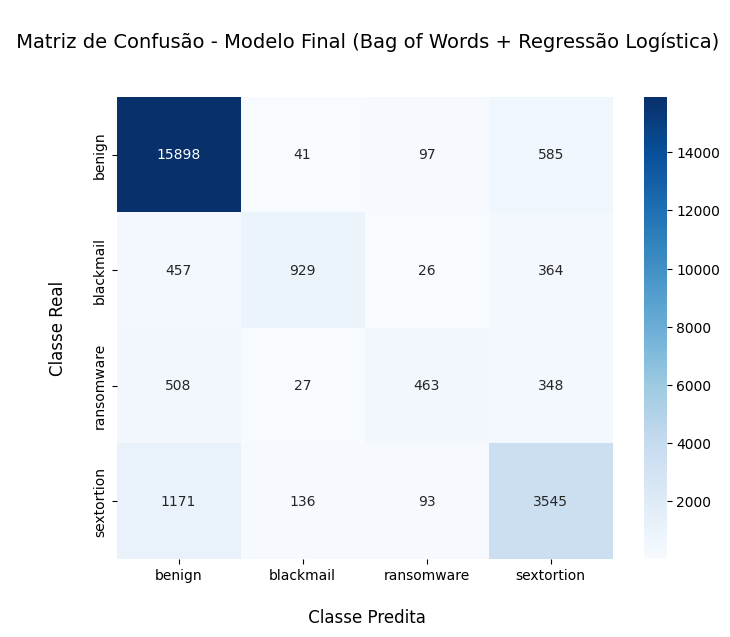

In [88]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definindo o modelo campeão com o melhor parâmetro encontrado
modelo_campeao_bow = LogisticRegression(C=0.001, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)

# 2. Treino final com TODO o conjunto de treino Bag of Words
modelo_campeao_bow.fit(X_treino_bow_std, y_treino)

# 3. Predição no conjunto de TESTE (que o modelo nunca viu)
y_pred_bow = modelo_campeao_bow.predict(X_teste_bow_std)

# 4. métricas
acuracia = accuracy_score(y_teste, y_pred_bow)
precisao = precision_score(y_teste, y_pred_bow, average='weighted')
recall = recall_score(y_teste, y_pred_bow, average='weighted')

print("\n" + "="*40)
print("RELATÓRIO DE AVALIAÇÃO FINAL - BAG OF WORDS - (TESTE)")
print("="*40)
print(f"Acurácia:  {acuracia:.4f}")
print(f"Precision: {precisao:.4f}")
print(f"Recall:    {recall:.4f}")
print("="*40)

# 6. Matriz de Confusão para análise visual
cm = confusion_matrix(y_teste, y_pred_bow)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('\n Matriz de Confusão - Modelo Final (Bag of Words + Regressão Logística)\n', fontsize=14, pad=20)
plt.ylabel('Classe Real\n', fontsize=12)
plt.xlabel('\n Classe Predita', fontsize=12)
plt.show()


RELATÓRIO DE AVALIAÇÃO FINAL - TF-IDF - (TESTE)
Acurácia:  0.8311
Precision: 0.8230
Recall:    0.8311


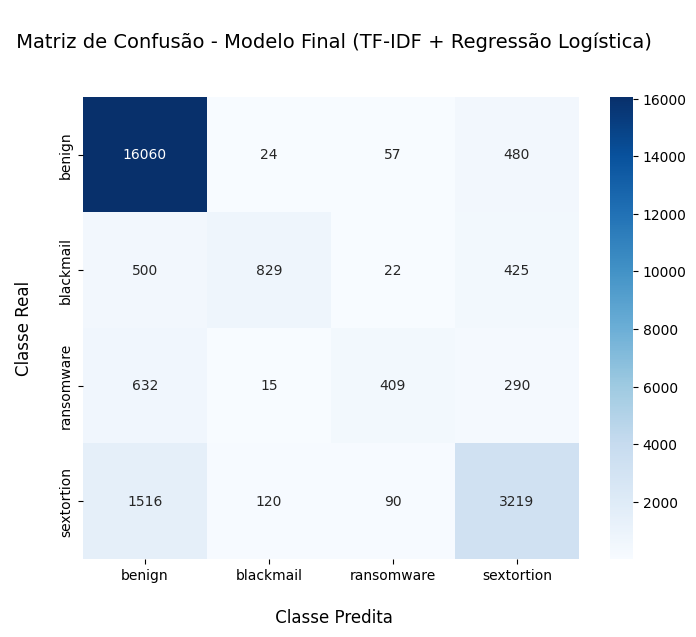

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definindo o modelo para TF-IDF
modelo_campeao_tfidf = LogisticRegression(C=0.001, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)

# 2. Treino final com TODO o conjunto de treino TF-IDF
modelo_campeao_tfidf.fit(X_treino_tfidf_std, y_treino)

# 3. Predição no conjunto de TESTE (que o modelo nunca viu)
y_pred_tfidf = modelo_campeao_tfidf.predict(X_teste_tfidf_std)

# 4. métricas
acuracia = accuracy_score(y_teste, y_pred_tfidf)
precisao = precision_score(y_teste, y_pred_tfidf, average='weighted')
recall = recall_score(y_teste, y_pred_tfidf, average='weighted')

print("\n" + "="*40)
print("RELATÓRIO DE AVALIAÇÃO FINAL - TF-IDF - (TESTE)")
print("="*40)
print(f"Acurácia:  {acuracia:.4f}")
print(f"Precision: {precisao:.4f}")
print(f"Recall:    {recall:.4f}")
print("="*40)

# 6. Matriz de Confusão para análise visual
cm = confusion_matrix(y_teste, y_pred_tfidf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('\n Matriz de Confusão - Modelo Final (TF-IDF + Regressão Logística)\n', fontsize=14, pad=20)
plt.ylabel('Classe Real\n', fontsize=12)
plt.xlabel('\n Classe Predita', fontsize=12)
plt.show()